In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix

In [2]:
# Data import
import sys
sys.path.append("..")
from data_loader import get_data
from cross_val_data import cross_validation

X_tr, X_val, X_te, y_tr, y_val, y_te = get_data()

In [4]:
print(f"X_tr: {X_tr.shape}, X_val: {X_val.shape}, X_te: {X_te.shape}")
print(f"y_tr: {y_tr.shape}, y_val: {y_val.shape}, y_te: {y_te.shape}")

X_tr: (48000, 784), X_val: (12000, 784), X_te: (10000, 784)
y_tr: (48000,), y_val: (12000,), y_te: (10000,)


In [5]:
print(np.unique(y_tr))

[0 1 2 3 4 5 6 7 8 9]


In [6]:
# Data reshape and setup
X_tr_cnn = X_tr.reshape(-1,28,28,1)
X_val_cnn = X_val.reshape(-1,28,28,1)
X_te_cnn = X_te.reshape(-1,28,28,1)

print("Reshaped data:")
print(f"X_tr: {X_tr_cnn.shape}")
print(f"X_val: {X_val_cnn.shape}")
print(f"X_te: {X_te_cnn.shape}")

Reshaped data:
X_tr: (48000, 28, 28, 1)
X_val: (12000, 28, 28, 1)
X_te: (10000, 28, 28, 1)


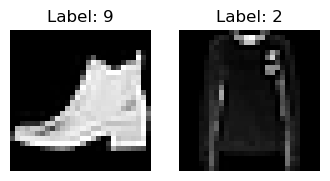

In [7]:
# Random shows data as image
fig, ax = plt.subplots(1,2,figsize=[4,4])
ax[0].imshow(X_tr_cnn[1325,:,:,0],cmap="gray")
ax[0].set_title(f'Label: {y_tr[1325]}')
ax[0].set_axis_off()

ax[1].imshow(X_tr_cnn[5678,:,:,0], cmap="gray")
ax[1].set_title(f'Label: {y_tr[5678]}')
ax[1].set_axis_off()

plt.show()

#### Train CNN

In [8]:
tr_fold, val_fold = cross_validation()

In [10]:
def model_1_layer(X_tr, y_tr, X_val, y_val):
    # Simplest model with 2 Convolution layers
    model = models.Sequential([
        # First Convolution
        # 32 filters with 3x3, activation with relu
        layers.Conv2D(64, kernel_size=(2,2), activation="relu", input_shape=(28,28,1)),
        # Pooling
        layers.MaxPool2D(pool_size=(2,2)),

        # Flatten
        layers.Flatten(),
        
        # Fully connected FNN
        layers.Dense(128, activation="relu"),
        # Output of P(y=k|x), k=0,1,...,9
        layers.Dense(10, activation="softmax")]
    )

    model.compile(optimizer="adam",
                loss="crossentropy",
                metrics=["accuracy"])

    history = model.fit(X_tr, y_tr, epochs=10,batch_size=64, validation_data=[X_val, y_val])

    return model, history

In [ ]:
def visualize_plot(history):
    fig, ax = plt.subplots(1,2,figsize=(12,5))
    ax[0].plot(history.history["loss"], label="Training Loss")
    ax[0].plot(history.history["val_loss"],label="Val Loss")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("Loss")
    ax[0].legend()

    ax[1].plot(history.history["accuracy"], label="Training Accuracy")
    ax[1].plot(history.history["val_accuracy"], label="Val Accuracy")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("Accuracy")
    ax[1].legend()

    plt.show()

In [17]:
# Simplest model with 2 Convolution layers
model = models.Sequential([
    # First Convolution
    # 32 filters with 3x3, activation with relu
    layers.Conv2D(32, kernel_size=(4,4), activation="relu", input_shape=(30,30,1)),
    # Pooling
    layers.MaxPool2D(pool_size=(2,2)),

    # Flatten
    layers.Flatten(),
    
    # Fully connected FNN
    layers.Dense(128, activation="relu"),
    # Output of P(y=k|x), k=0,1,...,9
    layers.Dense(10, activation="softmax")]
)

model.compile(optimizer="adam",
              loss="crossentropy",
              metrics=["accuracy"])

history_new = model.fit(X_tr_cnn_new, y_tr, epochs=10,batch_size=64, validation_data=[X_val_cnn_new, y_val])

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8427 - loss: 0.4399 - val_accuracy: 0.8817 - val_loss: 0.3348
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8932 - loss: 0.2952 - val_accuracy: 0.8910 - val_loss: 0.2981
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9100 - loss: 0.2490 - val_accuracy: 0.9013 - val_loss: 0.2726
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9210 - loss: 0.2159 - val_accuracy: 0.9110 - val_loss: 0.2507
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9304 - loss: 0.1899 - val_accuracy: 0.9103 - val_loss: 0.2487
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9379 - loss: 0.1665 - val_accuracy: 0.9145 - val_loss: 0.2429
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9449 - loss: 0.1487 - val_accuracy: 0.9174 - val_loss: 0.2461
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9520 - loss: 0.1298 - val_accuracy: 0

In [22]:
# Simplest model with 2 Convolution layers
model = models.Sequential([
    # First Convolution
    # 32 filters with 3x3, activation with relu
    layers.Conv2D(32, kernel_size=(4,4), activation="relu", input_shape=(30,30,1)),
    # Pooling
    layers.MaxPool2D(pool_size=(2,2)),

    # Flatten
    layers.Flatten(),
    
    # 1st layer Fully connected FNN
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.25,seed=178),

    # 2nd layer Fully connected FNN
    layers.Dense(128, activation="relu"),
    # Output of P(y=k|x), k=0,1,...,9
    layers.Dense(10, activation="softmax")]
)

model.compile(optimizer="adam",
              loss="crossentropy",
              metrics=["accuracy"])

history_new = model.fit(X_tr_cnn_new, y_tr, epochs=10,batch_size=64, validation_data=[X_val_cnn_new, y_val])

/opt/anaconda3/envs/cs178/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8204 - loss: 0.5015 - val_accuracy: 0.8849 - val_loss: 0.3223
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8841 - loss: 0.3223 - val_accuracy: 0.8934 - val_loss: 0.2884
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8975 - loss: 0.2779 - val_accuracy: 0.9021 - val_loss: 0.2679
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9081 - loss: 0.2473 - val_accuracy: 0.9087 - val_loss: 0.2505
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9159 - loss: 0.2264 - val_accuracy: 0.9108 - val_loss: 0.2473
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9226 - loss: 0.2054 - val_accuracy: 0.9147 - val_loss: 0.2422
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9280 - loss: 0.1901 - val_accuracy: 0.9168 - val_loss: 0.2456
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9335 - loss: 0.1757 - val_accuracy: 0